In [1]:
pip install numpy pandas scikit-learn tensorflow keras flask matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [2]:
#Traffic Flow Prediction using LSTM

In [3]:
#Accident Prediction using CNN

In [4]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

In [5]:
data = pd.read_csv('Traffic.csv') 
print(data.head())
print(data.info())

          Time  Date Day of the week  CarCount  BikeCount  BusCount  \
0  12:00:00 AM    10         Tuesday        31          0         4   
1  12:15:00 AM    10         Tuesday        49          0         3   
2  12:30:00 AM    10         Tuesday        46          0         3   
3  12:45:00 AM    10         Tuesday        51          0         2   
4   1:00:00 AM    10         Tuesday        57          6        15   

   TruckCount  Total Traffic Situation  
0           4     39               low  
1           3     55               low  
2           6     55               low  
3           5     58               low  
4          16     94            normal  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2976 entries, 0 to 2975
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Time               2976 non-null   object
 1   Date               2976 non-null   int64 
 2   Day of the week    2976 non-

In [6]:
# Convert 'Date' and 'Time' to a single datetime column
data['datetime'] = pd.to_datetime(data['Date'].astype(str) + ' ' + data['Time'], format='%d %I:%M:%S %p')

# Sort data by datetime to ensure proper sequence
data = data.sort_values('datetime').reset_index(drop=True)

In [7]:
# Extract features from the datetime column
data['hour'] = data['datetime'].dt.hour
data['minute'] = data['datetime'].dt.minute
data['day_of_week'] = data['datetime'].dt.dayofweek  # Monday=0, Sunday=6

In [8]:
from sklearn.preprocessing import LabelEncoder
# Encode the 'Traffic Situation' as numerical categories
le = LabelEncoder()
data['traffic_situation_encoded'] = le.fit_transform(data['Traffic Situation'])

# Check the unique values in the encoded traffic situations
print(data['traffic_situation_encoded'].unique())

[3 2 0 1]


In [9]:
from sklearn.preprocessing import MinMaxScaler

# Select numerical features to scale
features_to_scale = ['CarCount', 'BikeCount', 'BusCount', 'TruckCount', 'Total']
scaler = MinMaxScaler()
#Scaling
scaled_features = scaler.fit_transform(data[features_to_scale])

# Add scaled features back to the DataFrame
for i, feature in enumerate(features_to_scale):
    data[f'scaled_{feature}'] = scaled_features[:, i]

In [10]:
import numpy as np

In [11]:
#Creating time sequence for numpy

In [12]:
def create_sequences(data, time_steps=4):
    X, y = [], []
    for i in range(len(data) - time_steps):
        X.append(data[i:(i + time_steps), :])
        y.append(data[i + time_steps, -1])  # Predicting the 'Total' scaled count
    return np.array(X), np.array(y)

In [13]:
# Use relevant scaled features and traffic situation for the LSTM input
sequence_data = data[[f'scaled_{feature}' for feature in features_to_scale] + ['traffic_situation_encoded']].values
time_steps = 4  # using 1-hour sequence (4 steps of 15 minutes each)
X, y = create_sequences(sequence_data, time_steps)

In [14]:
# Split the dataset into training and validation sets
split_index = int(0.8 * len(X))
X_train, X_val = X[:split_index], X[split_index:]
y_train, y_val = y[:split_index], y[split_index:]

In [15]:
#Build and Train the LSTM Model

In [16]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input  # Ensure Input is imported

In [17]:

# Define the LSTM model with the Input layer
model = Sequential()
model.add(Input(shape=(X_train.shape[1], X_train.shape[2])))  # Define input shape
model.add(LSTM(units=50, return_sequences=True))  # First LSTM layer
model.add(Dropout(0.2))
model.add(LSTM(units=50, return_sequences=False))  # Second LSTM layer
model.add(Dropout(0.2))
model.add(Dense(units=25))  # Intermediate dense layer
model.add(Dense(units=1))   # Output layer for predicting the 'Total' vehicle count

In [18]:
# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

In [19]:
# Train the model
model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=10, batch_size=32)

Epoch 1/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - loss: 2.7794 - val_loss: 0.9585
Epoch 2/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.0383 - val_loss: 0.9587
Epoch 3/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.9224 - val_loss: 0.8930
Epoch 4/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.8964 - val_loss: 0.8053
Epoch 5/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.8631 - val_loss: 0.7930
Epoch 6/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.8451 - val_loss: 0.8085
Epoch 7/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.8033 - val_loss: 0.7793
Epoch 8/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.7945 - val_loss: 0.7842
Epoch 9/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.8069 - val_loss: 0.7898
Epoch 10/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.8214 - val_loss: 0.8098


In [20]:
# Print model summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 4, 50)               │          11,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 4, 50)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 50)                  │          20,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 50)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 25)                  │           1,275 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              26 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 98,705 (385.57 KB)

 Trainable params: 32,901 (128.52 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 65,804 (257.05 KB)

In [21]:
#Model Evaluation

In [22]:
# Predict on validation set
predictions = model.predict(X_val)

19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step


In [23]:
# Print the shape of the data used to fit the scaler
print("Shape of data used to fit scaler:", X_train.shape)  # Should be (num_samples, num_features)

Shape of data used to fit scaler: (2377, 4, 6)


In [24]:
import numpy as np

In [25]:
num_features = 6

In [26]:
# Verify scaler data shapes
print("Scaler min shape:", scaler.data_min_.shape)
print("Scaler scale shape:", scaler.scale_.shape)


Scaler min shape: (5,)
Scaler scale shape: (5,)


In [27]:
from sklearn.preprocessing import MinMaxScaler

In [28]:
scaler_y = MinMaxScaler()
scaler_y.fit(y_train.reshape(-1, 1))  # Reshape y_train to 2D array for fitting

MinMaxScaler()

In [29]:
predictions = model.predict(X_val)

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


In [30]:
predictions = predictions.reshape(-1, 1)
predictions = scaler_y.inverse_transform(predictions)  # Reverse the scaling to original values

In [31]:
y_val = y_val.reshape(-1, 1)
y_val = scaler_y.inverse_transform(y_val)

In [32]:
import matplotlib.pyplot as plt

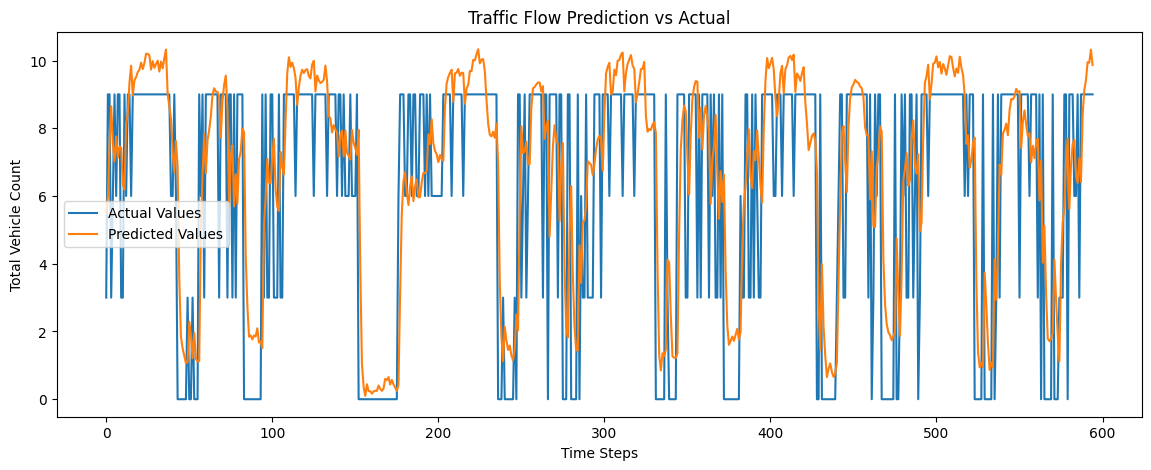

In [33]:
plt.figure(figsize=(14, 5))
plt.plot(y_val, label='Actual Values')
plt.plot(predictions, label='Predicted Values')
plt.title('Traffic Flow Prediction vs Actual')
plt.xlabel('Time Steps')
plt.ylabel('Total Vehicle Count')
plt.legend()
plt.show()

In [34]:
# Save the model
model.save('models/traffic_lstm.h5')

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import joblib  # For saving the model
print("Libraries installed and imported successfully!")

Libraries installed and imported successfully!


In [36]:
file_path = 'US_Accidents_March23.csv'  # File path relative to your project directory
df = pd.read_csv(file_path)

In [37]:
print(df.head())
print(df.info())  # To check data types and missing values
missing_values = df.isnull().sum()  # Checking for missing values
print(missing_values[missing_values > 0])
print(df.describe())
print(df['Severity'].value_counts())

    ID   Source  Severity           Start_Time             End_Time  \
0  A-1  Source2         3  2016-02-08 05:46:00  2016-02-08 11:00:00   
1  A-2  Source2         2  2016-02-08 06:07:59  2016-02-08 06:37:59   
2  A-3  Source2         2  2016-02-08 06:49:27  2016-02-08 07:19:27   
3  A-4  Source2         3  2016-02-08 07:23:34  2016-02-08 07:53:34   
4  A-5  Source2         2  2016-02-08 07:39:07  2016-02-08 08:09:07   

   Start_Lat  Start_Lng  End_Lat  End_Lng  Distance(mi)  ... Roundabout  \
0  39.865147 -84.058723      NaN      NaN          0.01  ...      False   
1  39.928059 -82.831184      NaN      NaN          0.01  ...      False   
2  39.063148 -84.032608      NaN      NaN          0.01  ...      False   
3  39.747753 -84.205582      NaN      NaN          0.01  ...      False   
4  39.627781 -84.188354      NaN      NaN          0.01  ...      False   

  Station   Stop Traffic_Calming Traffic_Signal Turning_Loop Sunrise_Sunset  \
0   False  False           False          F

In [38]:
df = df.dropna(subset=['Severity', 'Start_Time', 'End_Time', 'Temperature(F)', 'Visibility(mi)'])

In [39]:
# Convert date-time columns with error handling
df['Start_Time'] = pd.to_datetime(df['Start_Time'], errors='coerce', format='mixed')
df['End_Time'] = pd.to_datetime(df['End_Time'], errors='coerce', format='mixed')

In [40]:
# Check if there are any NaT values after conversion
nat_count_start = df['Start_Time'].isna().sum()
nat_count_end = df['End_Time'].isna().sum()

In [41]:
print(f"Number of NaT values in 'Start_Time': {nat_count_start}")
print(f"Number of NaT values in 'End_Time': {nat_count_end}")
df = df.dropna(subset=['Start_Time', 'End_Time'])

Number of NaT values in 'Start_Time': 0
Number of NaT values in 'End_Time': 0


In [42]:
# Confirming no NaT values remain
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 7524982 entries, 0 to 7728393
Data columns (total 46 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   ID                     object        
 1   Source                 object        
 2   Severity               int64         
 3   Start_Time             datetime64[ns]
 4   End_Time               datetime64[ns]
 5   Start_Lat              float64       
 6   Start_Lng              float64       
 7   End_Lat                float64       
 8   End_Lng                float64       
 9   Distance(mi)           float64       
 10  Description            object        
 11  Street                 object        
 12  City                   object        
 13  County                 object        
 14  State                  object        
 15  Zipcode                object        
 16  Country                object        
 17  Timezone               object        
 18  Airport_Code           obje

In [43]:
# Extract features from date-time
df['Hour'] = df['Start_Time'].dt.hour
df['DayOfWeek'] = df['Start_Time'].dt.dayofweek  # Monday=0, Sunday=6

In [44]:
# Checking the first few rows to ensure features were extracted correctly
print(df[['Start_Time', 'Hour', 'DayOfWeek']].head())

           Start_Time  Hour  DayOfWeek
0 2016-02-08 05:46:00     5          0
1 2016-02-08 06:07:59     6          0
2 2016-02-08 06:49:27     6          0
3 2016-02-08 07:23:34     7          0
4 2016-02-08 07:39:07     7          0


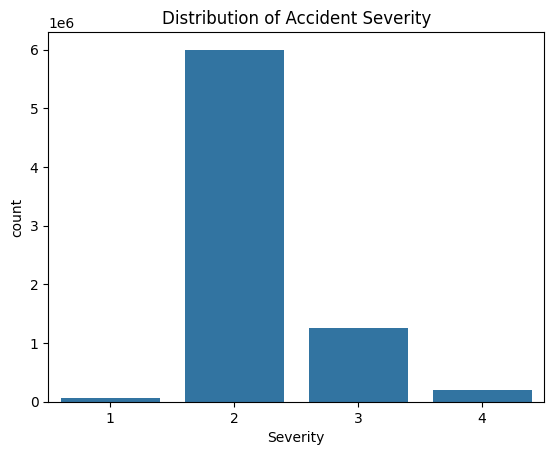

In [45]:
# Plotting the distribution of Severity
sns.countplot(x='Severity', data=df)
plt.title('Distribution of Accident Severity')
plt.show()

In [46]:
# Filtering numeric columns
numeric_df = df.select_dtypes(include=[np.number])

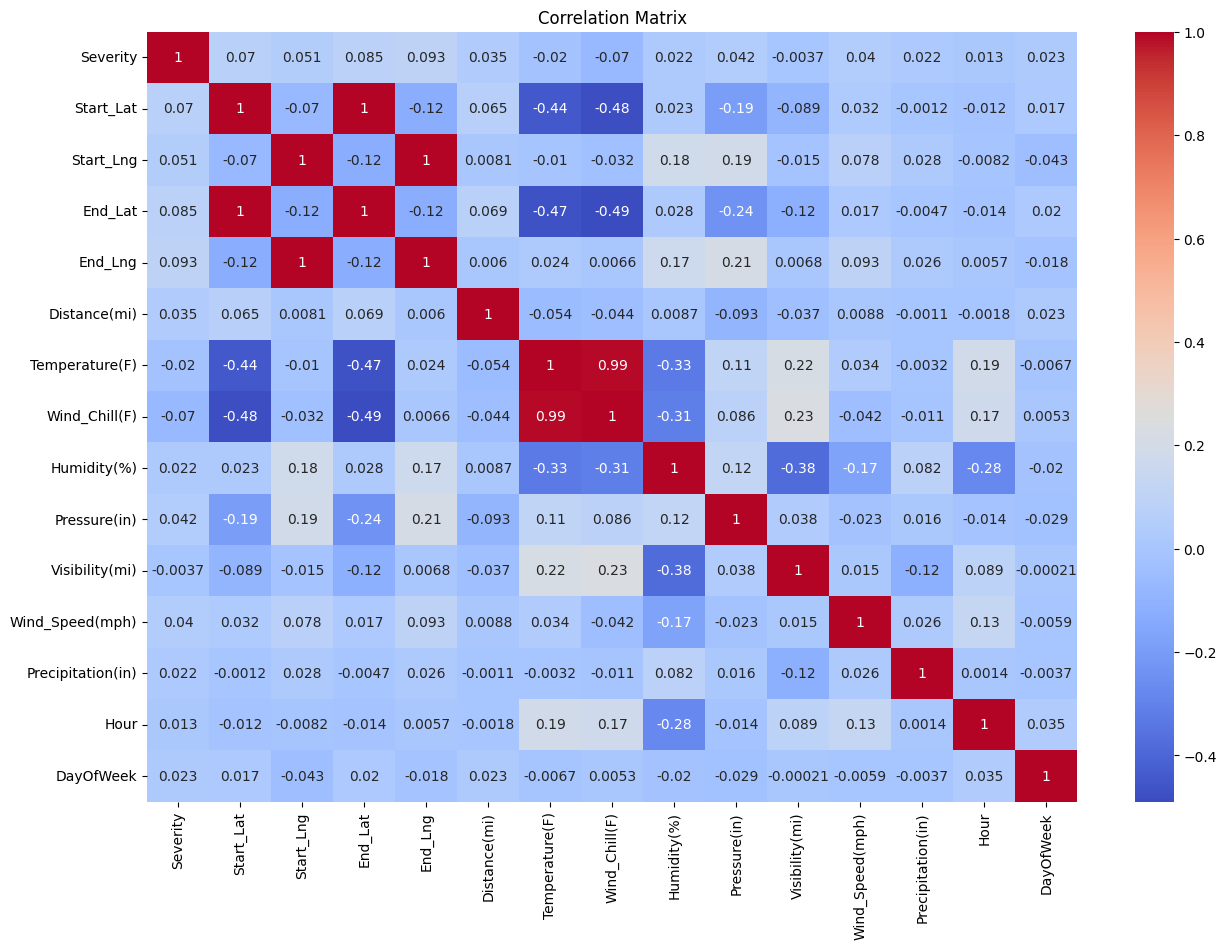

In [47]:
# Computing the correlation matrix
corr_matrix = numeric_df.corr()
# Plot the correlation matrix
plt.figure(figsize=(15,10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

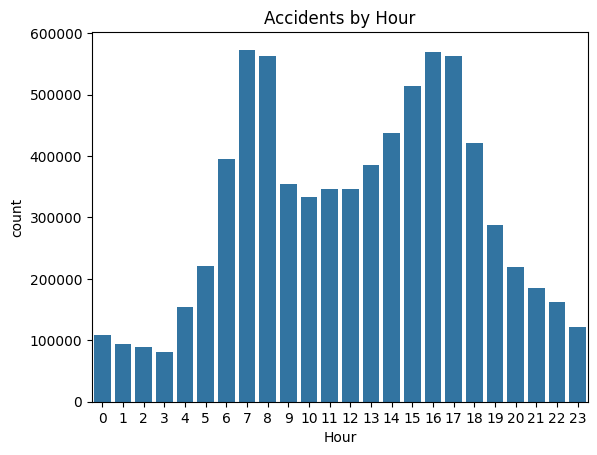

In [48]:
# Accidents by Hour
sns.countplot(x='Hour', data=df)
plt.title('Accidents by Hour')
plt.show()

In [49]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

In [50]:
# Example of splitting the data
X = df[['Temperature(F)', 'Visibility(mi)', 'Hour', 'DayOfWeek']]  # Use relevant features
y = df['Severity']  # Target variable

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train a model
model = RandomForestClassifier()
model.fit(X_train, y_train)

RandomForestClassifier()

In [51]:
# Save the model with a .pkl extension
joblib.dump(model, 'models/accident.pkl')

['models/accident.pkl']

In [52]:
# To load the model later
loaded_model = joblib.load('models/accident.pkl')

In [53]:
# Example of using the loaded model to make predictions
y_pred = loaded_model.predict(X_test)

# Evaluation metrics
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[     35   13213      55       1]
 [    120 1178074   19214    1445]
 [     44  237106   15552     729]
 [      3   36690    1547    1169]]
              precision    recall  f1-score   support

           1       0.17      0.00      0.01     13304
           2       0.80      0.98      0.88   1198853
           3       0.43      0.06      0.11    253431
           4       0.35      0.03      0.05     39409

    accuracy                           0.79   1504997
   macro avg       0.44      0.27      0.26   1504997
weighted avg       0.72      0.79      0.72   1504997



In [54]:
from keras.models import load_model
import pickle

# Step 1: Load the H5 model
model = load_model('traffic_lstm.h5')

# Step 2: Save the model as a .pkl file
with open('traffic_lstm.pkl', 'wb') as file:
    pickle.dump(model, file)

print("Model has been successfully converted to pkl format.")


Model has been successfully converted to pkl format.


In [55]:
joblib.dump(model, 'models/accident.h5')

['models/accident.h5']

In [60]:
from tensorflow.keras.models import load_model
import pickle

In [62]:
with open('C:/Users/pc/PycharmProjects/Final Project/accident.pkl', 'wb') as file:
    pickle.dump(model, file)
